## On the use of hierarchical Bayesian modelling for stochastic crack growth monitoring

### Case 2 - Modelling crack growth in ship structures using a spectral fatigue analysis and a stochastic modified Paris' law model

This notebook demonstrates the principles of the proposed hierarchical Bayesian modelling framework using data obtained from a physics-based stochastic simulation that generates crack growth data for structural components in ship structures, operating under realistic conditions. The framework employed to generate these results is presented in Makris et al. (2023).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

notebook_path = Path().absolute()
project_root = notebook_path.parent
sys.path.append(str(project_root))
from src.data_utils import SCGDataLoader

In [3]:
data_loader = SCGDataLoader()

In [4]:
data = data_loader.load_data()

In [5]:
%matplotlib inline

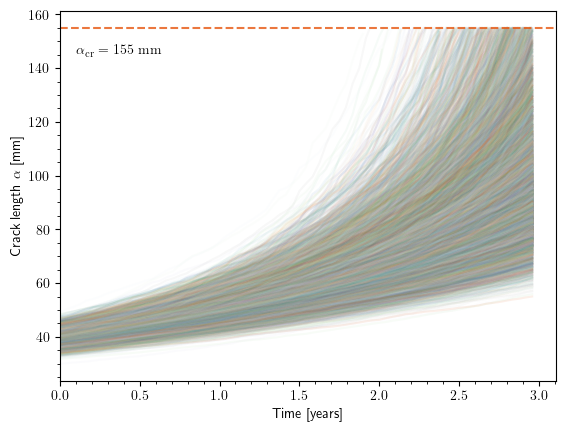

In [6]:
from src.visualisation import plot_scg_data

plot_scg_data(data["times"], data["crack_lengths"], save_fig_name="scg_data.pdf")

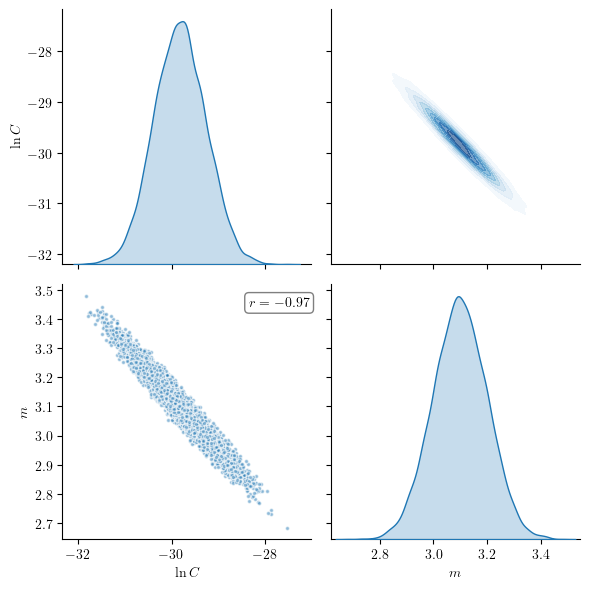

In [7]:
from src.visualisation import paris_params_pair_plot
paris_params_pair_plot(data["paris_c"], data["paris_m"], save_fig_name="paris_params_pair_plot.pdf")

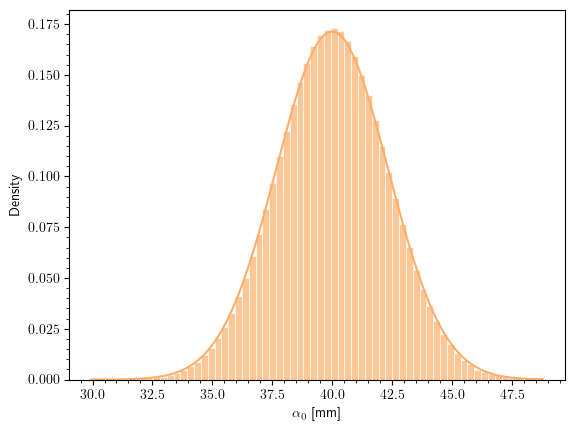

In [8]:
from src.visualisation import plot_initial_crack_length
plot_initial_crack_length(data["initial_crack_length"], save_fig_name="a0_hist.pdf")

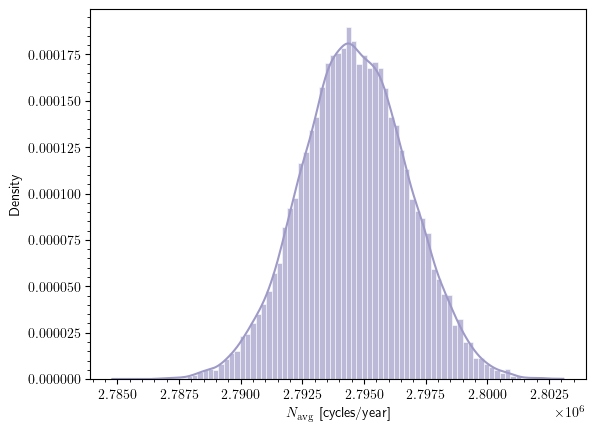

In [9]:
from src.visualisation import plot_avg_cycles
plot_avg_cycles(data["avg_cycles"], save_fig_name="avg_cycles_hist.pdf")

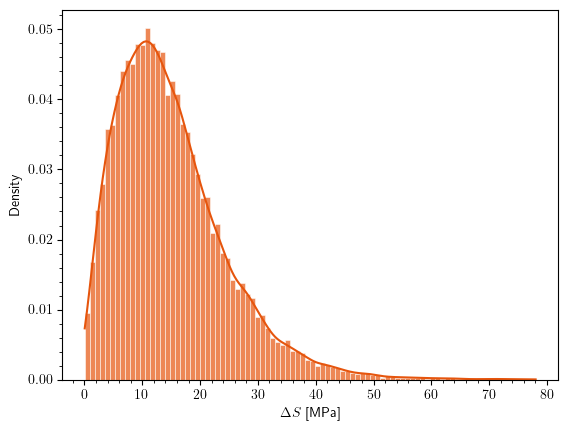

In [10]:
from src.visualisation import plot_stress_ranges
plot_stress_ranges(data["stress_ranges"], save_fig_name="stress_ranges_hist.pdf")

## Visualizing Selected Crack Growth Trajectories

Here we demonstrate the new functions for visualizing selected trajectories and observations.

In [11]:
# Import our new trajectory selector and observation generator
from src.data_utils import TrajectorySelector, CrackObservationGenerator
from src.visualisation import plot_selected_trajectories, plot_trajectories_with_observations

In [12]:
# First, let's select some trajectories with similar Paris law parameters
trajectory_selector = TrajectorySelector(data)

# Set target parameters for selection (similar to what we did in the HBM_for_SCG notebook)

# This will internally calculate target parameters based on the data statistics
trajectory_selector._set_target_parameters(scale_logc=-1.5, scale_m=1.5)

# Select trajectories that are within 1% of the standard deviation from the targets
selected_indices = trajectory_selector.select_by_radius(radius=0.01)
print(f"Found {len(selected_indices)} trajectories matching the criteria")

# Extract the selected trajectories
selected_trajectories = trajectory_selector.extract_trajectories(selected_indices)

# Print Paris parameters of selected trajectories
print("Paris parameters of selected trajectories:")
for i, (c, m) in enumerate(zip(selected_trajectories['paris_c'], selected_trajectories['paris_m'])):
    print(f"Trajectory {i+1}: C={c:.2e}, m={m:.4f}")

Found 3 trajectories matching the criteria
Paris parameters of selected trajectories:
Trajectory 1: C=4.80e-14, m=3.2491
Trajectory 2: C=4.82e-14, m=3.2482
Trajectory 3: C=4.79e-14, m=3.2494


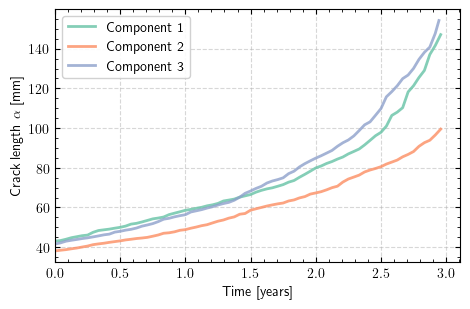

In [14]:
# Visualize the selected trajectories
fig, ax = plot_selected_trajectories(
    times=selected_trajectories['times'],
    crack_lengths=selected_trajectories['crack_lengths'],
    labels=[f"Component {i+1}" for i in range(len(selected_indices))],
    cmap_name='Set2',
    figsize=(4.8, 3.2),
    alpha=0.8,
    save_fig_name="selected_trajectories_spectral.svg"
)

## Simulating and Visualizing Crack Observations

Now let's generate simulated observations from these trajectories and visualize them.

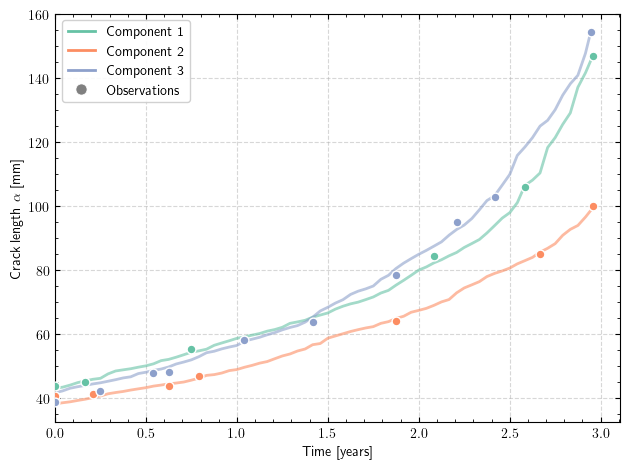

In [15]:
# Create an observation generator based on the selected trajectories
obs_generator = CrackObservationGenerator(selected_trajectories, random_seed=42)

# Generate observations using random sampling with noise
observations = obs_generator.create_observations(
    n_points=[6, 7, 10],           # 10 observations per trajectory
    strategy='random',     # Random sampling across the timeline
    noise_std=1.5,           # 1mm standard deviation measurement noise
    include_endpoints=True,  # Always include start and end points
    random_seed=42
)

# Visualize the trajectories with observations
fig, ax = plot_trajectories_with_observations(
    times=selected_trajectories['times'],
    crack_lengths=selected_trajectories['crack_lengths'],
    obs_times=observations['times'],
    obs_lengths=observations['noisy_crack_lengths'],
    labels=[f"Component {i+1}" for i in range(len(selected_indices))],
    cmap_name='Set2',
    figsize=(6.4, 4.8),
    traj_alpha=0.6,        # Make the trajectories slightly transparent
    obs_alpha=1.0,         # Make the observations more visible
    marker_size=40,        # Increase marker size for visibility
    save_fig_name="spectral_obs_random.pdf"
)

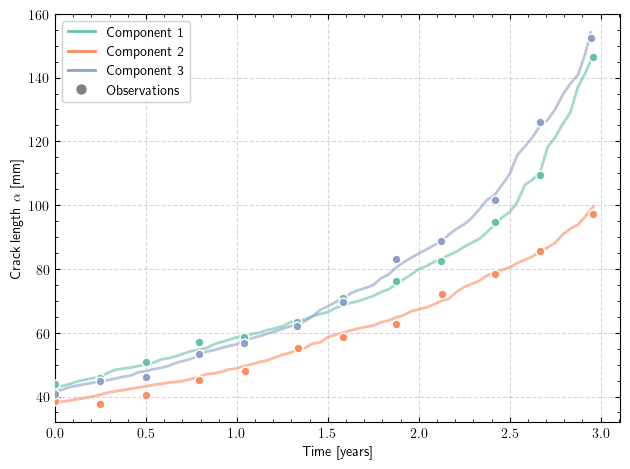

In [16]:
# Let's also try uniform sampling, which is more systematic
uniform_observations = obs_generator.create_observations(
    n_points=12,            # 8 observations per trajectory
    strategy='uniform',    # Evenly spaced observations
    noise_std=1.5,           # Slightly higher noise for demonstration
    include_endpoints=True,
    random_seed=42
)

# Visualize with uniform sampling
fig, ax = plot_trajectories_with_observations(
    times=selected_trajectories['times'],
    crack_lengths=selected_trajectories['crack_lengths'],
    obs_times=uniform_observations['times'],
    obs_lengths=uniform_observations['noisy_crack_lengths'],
    labels=[f"Component {i+1}" for i in range(len(selected_indices))],
    cmap_name='Set2',
    figsize=(6.4, 4.8),
    traj_alpha=0.6,
    obs_alpha=1.0,
    marker_size=40,
    save_fig_name="spectral_obs_uni.pdf"
)

# Add title to indicate this is uniform sampling
# ax.set_title("Crack Growth Trajectories with Uniformly Sampled Observations")

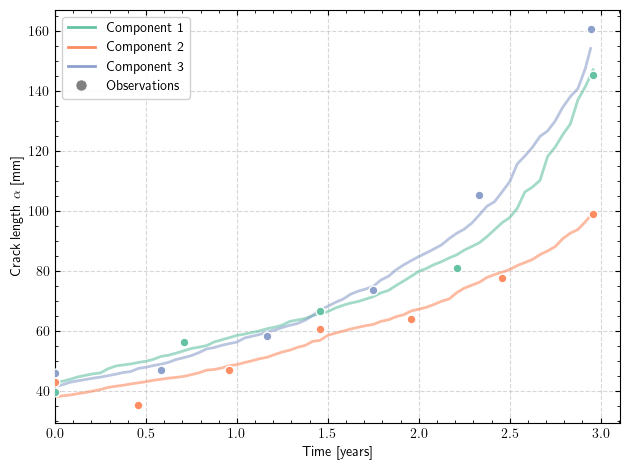

In [17]:
# Finally, let's demonstrate different noise levels
# Higher noise to illustrate measurement uncertainty
high_noise_observations = obs_generator.create_observations(
    n_points=[5, 7, 6],    # Different number of points for each trajectory
    strategy='uniform',
    noise_std=3.0,           # Higher noise level
    include_endpoints=True,
    random_seed=123
)

fig, ax = plot_trajectories_with_observations(
    times=selected_trajectories['times'],
    crack_lengths=selected_trajectories['crack_lengths'],
    obs_times=high_noise_observations['times'],
    obs_lengths=high_noise_observations['noisy_crack_lengths'],
    labels=[f"Component {i+1}" for i in range(len(selected_indices))],
    cmap_name='Set2',
    figsize=(6.4, 4.8),
    traj_alpha=0.6,
    obs_alpha=1.0,
    marker_size=40,
    save_fig_name="spectral_obs_uni_high_noise.pdf"
)

# Add title to indicate the high noise level
# ax.set_title(r"Crack Growth Trajectories with High Measurement Uncertainty ($\sigma = 3.0$ mm)")

# Add text to explain what's being shown
# ax.text(0.02, 0.02, 
#         "Solid lines: True crack growth trajectories\nPoints: Simulated measurements with noise", 
#         transform=ax.transAxes, 
#         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'),
#         fontsize=9)

## Bayesian Inference for Crack Growth Parameters

In this section, we'll use the Bayesian model we've implemented to infer Paris law parameters from observed crack growth data. We'll start with a single component and then expand to multiple components.

In [18]:
import numpy as np

In [19]:
import numpyro.distributions as dist
from src.bayesian_models import STLBayesianModel
from src.visualisation import plot_posterior_trace

# Set a seed for reproducibility
np.random.seed(42)

In [31]:
# First, let's define our priors for the model
# These priors are based on domain knowledge about Paris law parameters
priors = {
    "logc": dist.Normal(-30.0, 2.0),      # Natural log of C parameter
    "m": dist.HalfNormal(2.0),           # Paris law exponent
    "ds": dist.Weibull(14.9, 1.6),           # Stress range (MPa)
    "noise_std": dist.HalfNormal(2.0)     # Observation noise (mm)
}

In [42]:
# Component index to start with
component_idx = 2

# Extract the true parameters for this component from the selected trajectories
true_logc = np.log(selected_trajectories['paris_c'][component_idx])
true_m = selected_trajectories['paris_m'][component_idx]
true_a0 = selected_trajectories['initial_crack_length'][component_idx]

print(f"True parameters for component {component_idx + 1}:")
print(f"logC: {true_logc:.4f}")
print(f"m: {true_m:.4f}")
print(f"a0: {true_a0:.4f}")

True parameters for component 3:
logC: -30.6687
m: 3.2494
a0: 41.5960


In [43]:
import warnings
warnings.filterwarnings("ignore")

In [44]:
# Create the Bayesian model
# We'll use the uniform observations we created earlier
model = STLBayesianModel(priors=priors, crack_growth_data=uniform_observations)

# Run inference with MCMC
# For demonstration, we're using fewer samples than we would in practice
results = model.run_inference(
    component_idx=component_idx,
    navg = 2.8e6,       # Average cycles per year
    num_warmup=2000,    # Number of warmup steps
    num_samples=2000,   # Number of samples to draw
    num_chains=4,       # Number of chains to run
    progress_bar=True   # Show progress bar during sampling
)

sample: 100%|██████████| 4000/4000 [00:02<00:00, 1392.95it/s, 1023 steps of size 1.88e-03. acc. prob=0.91]


In [45]:
# Print full posterior summary
model.summarise_posterior(print_summary=True)
# Print summary statistics
print("\nPosterior summary:")
print(f"Inferred logC: {results['summary']['mean']['logc']:.4f} ± {results['summary']['sd']['logc']:.4f}")
print(f"Inferred m: {results['summary']['mean']['m']:.4f} ± {results['summary']['sd']['m']:.4f}")
print(f"Inferred noise_std: {results['summary']['mean']['noise_std']:.4f} ± {results['summary']['sd']['noise_std']:.4f}")

                                mean     sd   hdi_3%  hdi_97%  mcse_mean  \
ds                             8.894  4.049    2.550   16.135      0.132   
logc                         -30.787  1.711  -34.002  -27.590      0.057   
m                              3.985  0.155    3.691    4.273      0.004   
noise_std                      2.207  0.515    1.358    3.203      0.016   
predicted_crack_lengths[0]    44.696  0.101   44.509   44.890      0.003   
predicted_crack_lengths[1]    48.273  0.215   47.894   48.703      0.006   
predicted_crack_lengths[2]    52.442  0.340   51.836   53.119      0.009   
predicted_crack_lengths[3]    57.358  0.477   56.476   58.279      0.013   
predicted_crack_lengths[4]    63.233  0.622   62.095   64.453      0.016   
predicted_crack_lengths[5]    70.368  0.769   68.878   71.793      0.020   
predicted_crack_lengths[6]    79.194  0.903   77.479   80.925      0.023   
predicted_crack_lengths[7]    90.363  1.002   88.505   92.314      0.024   
predicted_cr

In [46]:
model.check_rhat()

R-hat Convergence Diagnostics:
Threshold: 1.01
--------------------------------------------------
ds                       : 1.0000 ✓ 
logc                     : 1.0000 ✓ 
m                        : 1.0000 ✓ 
noise_std                : 1.0000 ✓ 
predicted_crack_lengths[0]: 1.0000 ✓ 
predicted_crack_lengths[1]: 1.0000 ✓ 
predicted_crack_lengths[2]: 1.0000 ✓ 
predicted_crack_lengths[3]: 1.0000 ✓ 
predicted_crack_lengths[4]: 1.0000 ✓ 
predicted_crack_lengths[5]: 1.0000 ✓ 
predicted_crack_lengths[6]: 1.0000 ✓ 
predicted_crack_lengths[7]: 1.0000 ✓ 
predicted_crack_lengths[8]: 1.0000 ✓ 
predicted_crack_lengths[9]: 1.0000 ✓ 
predicted_crack_lengths[10]: 1.0000 ✓ 

Convergence Summary:
Parameters with R-hat ≤ 1.01: 15/15
Convergence rate: 100.0%
Max R-hat: 1.0000
✅ All variable parameters have converged!


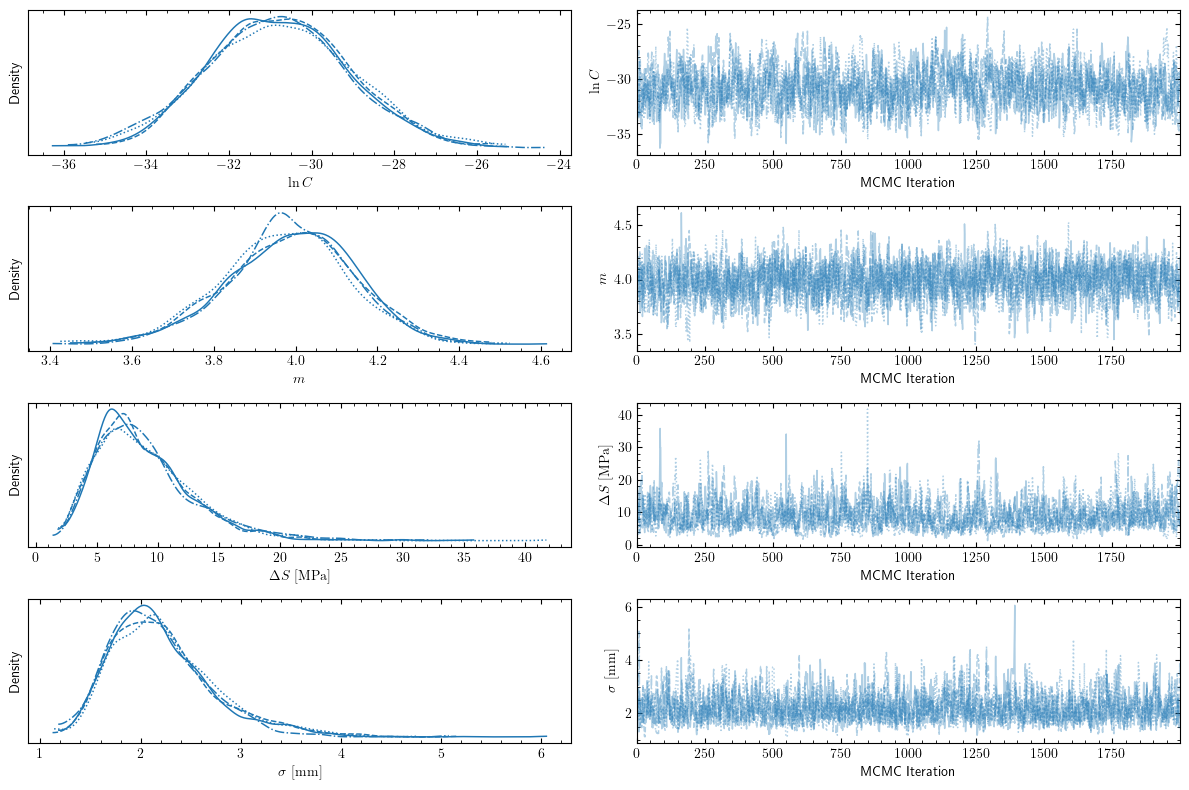

In [47]:
# Visualize posterior distributions
var_names = ["logc", "m", "ds", "noise_std"]
plot_var_names= [r"$\ln C$",  r"$m$", r"$\Delta S \ \mathrm{[MPa]}$", r"$\sigma \ \mathrm{[mm]}$"]
plot_posterior_trace(results['samples'], var_names=var_names, plot_var_names=plot_var_names,
                      save_fig_name="post_trace_stl_spectral_c3.pdf", compact=True)

## Comparing Prior and Posterior Distributions

We can use the new `plot_prior_posterior_comparison` function to visualize both prior and posterior distributions alongside the true parameter values and the posterior mode.

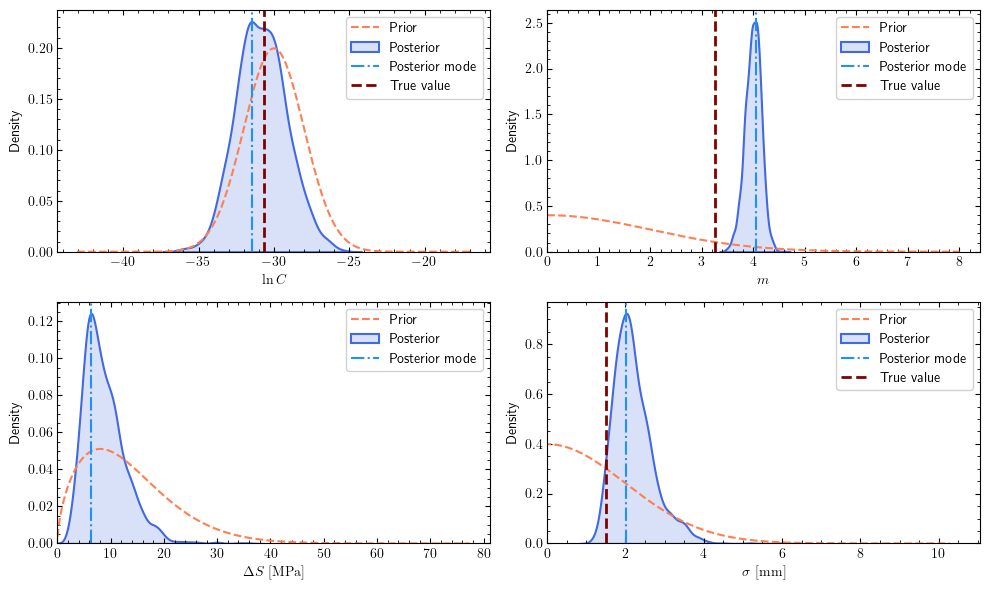

In [48]:
# Import necessary modules
import numpy as np
import numpyro.distributions as dist
from src.visualisation import plot_prior_posterior_comparison

# # Define the priors (same as used in the model)
# priors = {
#     "logc": dist.Normal(-30.0, 2.0),      # Natural log of C parameter
#     "m": dist.Normal(3.2, 0.5),           # Paris law exponent
#     "ds": dist.Gamma(5.0, 0.3),           # Stress range (MPa)
#     "noise_std": dist.HalfNormal(2.0)     # Observation noise (mm)
# }

# Define the true values (for demonstration)
true_values = {
    "logc": true_logc,
    "m": true_m,
    "noise_std": 1.5  # Noise used in generating observations
}

# Extract posterior samples
posterior_samples = results['samples']

# Define nice display names for plotting
plot_labels = {
    "logc": r"$\ln C$",
    "m": r"$m$",
    "ds": r"$\Delta S \ \mathrm{[MPa]}$",
    "noise_std": r"$\sigma \ \mathrm{[mm]}$"
}

# Create the comparison plot with extended prior range for better visualization
fig, axes = plot_prior_posterior_comparison(
    posterior_samples=posterior_samples,
    prior_dists=priors,
    true_values=true_values,
    var_names=var_names,
    plot_var_names=plot_labels,
    figsize=(10.0, 6.0),
    n_cols=2,
    point_estimate='mode',
    save_fig_name="prior_post_comp_stl_spectral_c3.pdf",
    use_first_chain_only=True,
    prior_range_extension=2.5
)

In [49]:
# Generate predictions using the preferred posterior predictive sampling method
# Note: The legacy generate_predictions method is deprecated
posterior_predictive_output = model.generate_posterior_predictive(
    num_samples=1000,
    component_idx=component_idx,
    navg=2.8e6,
    random_seed=42
)

In [50]:
# Use the new visualization function to plot posterior predictive samples
from src.visualisation import plot_posterior_predictive_stl

# Get times and data for plotting
true_times = selected_trajectories['times'][component_idx]
true_crack_lengths = selected_trajectories['crack_lengths'][component_idx]
observed_times = uniform_observations['times'][component_idx]
observed_crack_lengths = uniform_observations['noisy_crack_lengths'][component_idx]


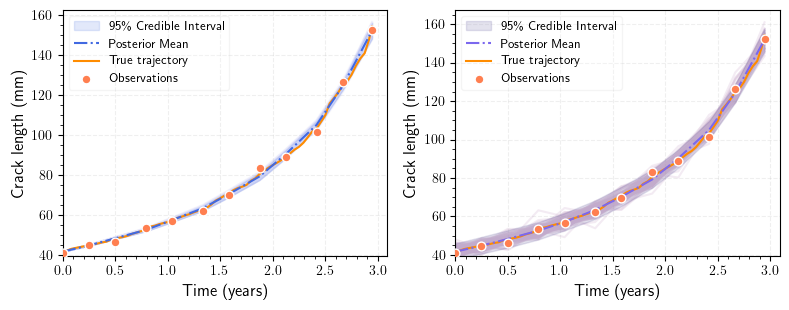

In [52]:
# Plot posterior predictive samples with true values and observations
fig1, ax1, stats1 = plot_posterior_predictive_stl(
    posterior_predictions=posterior_predictive_output,
    true_times=true_times,
    true_crack_lengths=true_crack_lengths,
    observed_times=observed_times,
    observed_crack_lengths=observed_crack_lengths,
    max_samples=100,
    figsize=(8, 3.2),
    save_fig_name="post_pred_stl_spectral_c3.pdf"
)

## Using the Output Utilities Module for Parameter Comparison

We'll use the new `output_utils` module to calculate error metrics and create formatted comparison tables for our Bayesian inference results across different components.

In [53]:
# Ignore warnings about available devices for numpyro
import warnings
warnings.filterwarnings("ignore")

In [54]:
# Now let's run the model on all three components to compare performance
component_results = []

for i in range(len(selected_indices)):
    print(f"\nRunning inference for component {i+1}...")
    
    # Extract true parameters
    true_logc = np.log(selected_trajectories['paris_c'][i])
    true_m = selected_trajectories['paris_m'][i]
    true_a0 = selected_trajectories['initial_crack_length'][i]
    
    print(f"True parameters for component {i + 1}:")
    print(f"logC: {true_logc:.4f}")
    print(f"m: {true_m:.4f}")
    print(f"a0: {true_a0:.4f}")
    
    # Create a new model for each component
    # For efficiency, use fewer samples for this comparison
    model = STLBayesianModel(priors=priors, crack_growth_data=uniform_observations)
    results = model.run_inference(
        component_idx=i,
        num_warmup=2000,
        num_samples=2000,
        num_chains=2,
        progress_bar=True
    )
    
    # Store results
    component_results.append({
        'index': i,
        'true_params': {
            'logc': true_logc,
            'm': true_m,
            'a0': true_a0,
            'noise_std': 1.5  # The true noise std used for generating observations
        },
        'inferred_params': {
            'logc': results['samples']['logc'],
            'm': results['samples']['m'],
            'ds': results['samples']['ds'],
            'noise_std': results['samples']['noise_std'],
        }
    })


Running inference for component 1...
True parameters for component 1:
logC: -30.6669
m: 3.2491
a0: 43.0770


sample: 100%|██████████| 4000/4000 [00:02<00:00, 1460.59it/s, 1023 steps of size 2.13e-03. acc. prob=0.95]



Running inference for component 2...
True parameters for component 2:
logC: -30.6630
m: 3.2482
a0: 38.1200


sample: 100%|██████████| 4000/4000 [00:02<00:00, 1560.23it/s, 1023 steps of size 3.33e-03. acc. prob=0.94]



Running inference for component 3...
True parameters for component 3:
logC: -30.6687
m: 3.2494
a0: 41.5960


sample: 100%|██████████| 4000/4000 [00:02<00:00, 1384.70it/s, 1023 steps of size 1.83e-03. acc. prob=0.93]


In [55]:
from src.output_utils import create_comparison_summary, save_comparison_summary

In [56]:
comparison_df = create_comparison_summary(component_results)
display(comparison_df.T)

,0,1,2
Component,Component 1,Component 2,Component 3
logc_target,-30.66693,-30.663003,-30.66868
logc_mean,-30.972038,-30.063364,-30.743006
logc_std,1.901179,1.725368,1.749598
logc_hdi_lower,-34.768806,-33.194183,-34.442909
logc_hdi_upper,-27.452162,-26.555189,-27.495651
logc_rmse,1.925507,1.826599,1.751176
logc_mape,5.06309,4.732135,4.542446
m_target,3.2491,3.2482,3.2494
m_mean,4.525147,3.545414,3.986489


In [51]:
save_comparison_summary(comparison_df, "stl_spectral_comparison_summary", "csv")

'/Users/nikos/Library/CloudStorage/OneDrive-Personal/Research (NTUA)/Postdoctoral Research/Stochastic Crack Growth Monitoring/Code/outputs/stl_spectral_comparison_summary.csv'

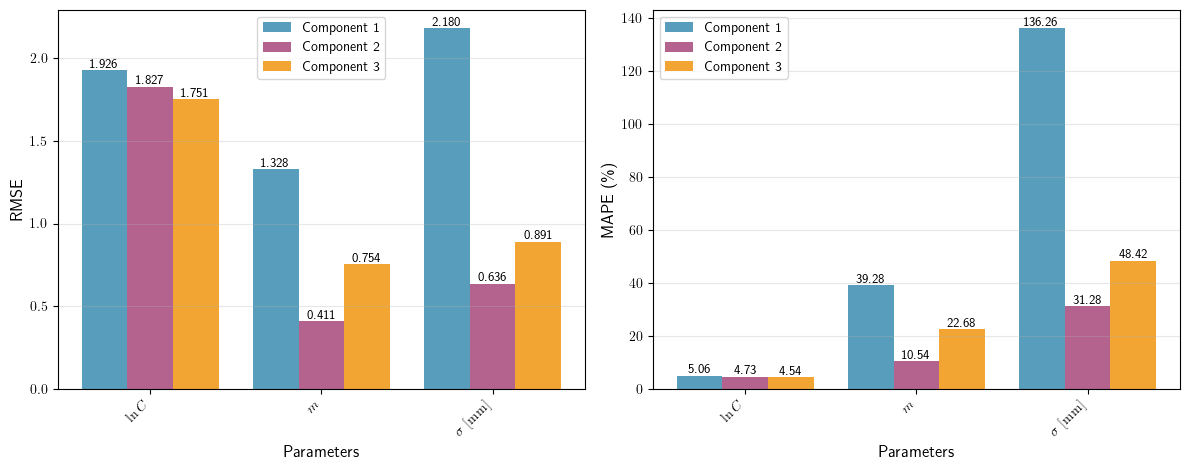

In [57]:
from src.visualisation import plot_performance_metrics
# Plot performance metrics for the comparison
fig, ax = plot_performance_metrics(summary_df=comparison_df,
                                   parameter_labels=plot_labels,
                                   figsize=(12., 4.8),
                                   colors=['#2E86AB', '#A23B72', '#F18F01'],
                                   save_fig_name="stl_performance_comparison_spectral.pdf")

### Multi-task Learning

In multi-task learning, we'll try to learn all tasks simultaneously by employing a hierarchical Bayesian model whose structure allows us to encode a degree of domain knowledge about the crack growth process. This model will treat the Paris law parameters (`logC`, `m`) and observation noise (`σ`) as **population-level (fixed effects)** parameters shared across all components, while inferring component-specific **stress ranges** (`Δσᵢ`) as **random effects**. This is aligned with the data generation process and also consistent with our physical understanding of the response behaviour of structurally similar components subjected to potentially different operational conditions on a ship hull structure.

To begin with, we will consider a fully hierarchical structure where the stress ranges are assumed to follow a Weibull distribution whose hyperparameters are treated as fixed effects and thus inferred from data. This implies that we treat individual stress ranges as instances of a common, population-level distribution which describes the accumulated stress ranges that drive fatigue crack growth on the assumed population of structural components.

Our modelling approach features two key assumptions derived from the inherent nature of the Paris law model. Namely:
- We assume a constant average number of cycles during crack growth, representing an equivalent loading frequency. This is assumed to be the mean period from the simulated loading data.
- We also assume a constant stress range throughout crack propagation, thus representing an equivalent stress range over the entire monitoring timeline.

These assumptions were also made for the single-task learning implementation. Let's begin our implementation by defining the hierarchical Bayesian model. We start by setting up the configuration dictionaries for the model priors.

In [58]:
# Define priors for Multi-Task Learning (MTL) with conditional hyperpriors
import numpyro.distributions as dist

# MTL priors for shared parameters (fixed effects)
mtl_priors = {
    "logc": dist.Normal(-30.0, 2.0),       # Shared Paris law C parameter
    "m": dist.HalfNormal(2.0),            # Shared Paris law exponent
    "noise_std": dist.HalfNormal(2.0)      # Shared observation noise
}

# Optional hyperpriors for stress range distribution (enables hierarchical modeling)
# When provided, stress ranges follow: ds[i] ~ Weibull(concentration, scale)
# When None, stress ranges are i.i.d. with fixed Weibull(14.9, 1.6) prior
hyperpriors = {
    "weibull_concentration": dist.Gamma(10.0, 1.0),  # Shape parameter for ds distribution
    "weibull_scale": dist.Gamma(15.0, 1.0)           # Scale parameter for ds distribution
}

Now we can create an instance of the hierarchical model in Numpyro using our `MTLBayesianModel` class which takes the observations and configuration dictionaries as inputs.

In [59]:
# Create MTL Bayesian model with conditional hyperpriors
from src.bayesian_models import MTLBayesianModel

# Create the hierarchical MTL model
# The hyperpriors argument enables conditional hyperprior functionality
mtl_model = MTLBayesianModel(
    priors=mtl_priors,                    # Fixed effects priors
    crack_growth_data=uniform_observations, # Multi-component observations
    hyperpriors=hyperpriors               # Enables hierarchical stress range modeling
)

print("MTL Model Configuration:")
print(f"- Number of components: {len(uniform_observations['times'])}")
print(f"- Shared parameters: {list(mtl_priors.keys())}")
print(f"- Component-specific parameters: stress ranges (ds)")
print(f"- Hyperprior mode: {'Hierarchical' if hyperpriors else 'Simple'}")
print(f"- Observations per component: {[len(times) for times in uniform_observations['times']]}")

MTL Model Configuration:
- Number of components: 3
- Shared parameters: ['logc', 'm', 'noise_std']
- Component-specific parameters: stress ranges (ds)
- Hyperprior mode: Hierarchical
- Observations per component: [12, 12, 12]


We will now use the `run_inference` method of the class to run inference. We can set up the number of chains to run simultaneously, alongside the number of warm-up steps for NUTS and the final number of posterior draws. Note that the average cycles per year can be tuned here, since it plays a role in the likelihood computation and it's not a core parameter of the Bayesian model. It's important to sample multiple chains to ensure that we can compute convergence diagnostics. We should also note here that there exist no target stress ranges per se, so we will only consider the inferred parameters!

In [60]:
# Run hierarchical MTL inference
print("Running hierarchical Multi-Task Learning inference...")
print("This jointly learns from all components while sharing information about:")
print("- Material properties (logC, m)")
print("- Measurement system (noise_std)")
print("- Stress range population distribution (via hyperpriors)")

mtl_results = mtl_model.run_inference(
    navg=2.8e6,           # Average cycles per year
    num_warmup=2000,      # MCMC warmup steps
    num_samples=2000,     # MCMC samples to collect
    num_chains=4,         # Number of parallel chains
    progress_bar=True     # Show progress during sampling
)
print("\nInference completed!")

Running hierarchical Multi-Task Learning inference...
This jointly learns from all components while sharing information about:
- Material properties (logC, m)
- Measurement system (noise_std)
- Stress range population distribution (via hyperpriors)


sample: 100%|██████████| 4000/4000 [00:05<00:00, 674.17it/s, 15 steps of size 2.63e-03. acc. prob=0.94]  



Inference completed!


In [61]:
import numpy as np
# Extract the true parameters for this component from the selected trajectories
true_logc = np.log(selected_trajectories['paris_c'][0])
true_m = selected_trajectories['paris_m'][0]
# Print information about the inference
print(f"Inferred shared parameters:")
print(f"  logC: {mtl_results['summary']['mean']['logc']:.4f} ± {mtl_results['summary']['sd']['logc']:.4f} (true: {true_logc:.4f})")
print(f"  m: {mtl_results['summary']['mean']['m']:.4f} ± {mtl_results['summary']['sd']['m']:.4f} (true: {true_m:.4f})")
print(f"  noise_std: {mtl_results['summary']['mean']['noise_std']:.4f} ± {mtl_results['summary']['sd']['noise_std']:.4f} (true: 1.5 mm)")

print(f"\nLearned population distribution parameters:")
print(f"  Weibull concentration: {mtl_results['summary']['mean']['weibull_concentration']:.3f} ± {mtl_results['summary']['sd']['weibull_concentration']:.3f}")
print(f"  Weibull scale: {mtl_results['summary']['mean']['weibull_scale']:.3f} ± {mtl_results['summary']['sd']['weibull_scale']:.3f}")

print(f"\nInferred component stress ranges:")
for i in range(3):
    mean_ds = mtl_results['summary']['mean'][f'ds[{i}]']
    sd_ds = mtl_results['summary']['sd'][f'ds[{i}]']
    print(f"  Component {i+1}: {mean_ds:.2f} ± {sd_ds:.2f} MPa")

Inferred shared parameters:
  logC: -31.5420 ± 1.2570 (true: -30.6669)
  m: 4.1600 ± 0.1560 (true: 3.2491)
  noise_std: 2.9050 ± 0.3850 (true: 1.5 mm)

Learned population distribution parameters:
  Weibull concentration: 8.189 ± 2.346
  Weibull scale: 16.839 ± 4.070

Inferred component stress ranges:
  Component 1: 8.00 ± 2.29 MPa
  Component 2: 8.00 ± 2.29 MPa
  Component 3: 8.20 ± 2.35 MPa


We can summarise inference results by printing the main posterior statistics and convergence metrics, alongside KDEs of the parameter posterior densities and their corresponding trace-plots.

In [62]:
# Print full posterior summary
mtl_model.summarise_posterior(print_summary=True)
# Print summary statistics
print("\nPosterior summary:")

                                   mean     sd   hdi_3%  hdi_97%  mcse_mean  \
ds[0]                             8.002  2.295    4.052   12.309      0.078   
ds[1]                             8.003  2.289    4.194   12.429      0.078   
ds[2]                             8.200  2.354    4.075   12.541      0.080   
logc                            -31.542  1.257  -33.870  -29.179      0.040   
m                                 4.160  0.156    3.852    4.439      0.003   
noise_std                         2.905  0.385    2.253    3.664      0.007   
predicted_crack_lengths[0, 0]    45.983  0.087   45.826   46.151      0.002   
predicted_crack_lengths[0, 1]    49.311  0.182   48.979   49.666      0.004   
predicted_crack_lengths[0, 2]    53.159  0.288   52.646   53.729      0.006   
predicted_crack_lengths[0, 3]    57.656  0.402   56.928   58.447      0.008   
predicted_crack_lengths[0, 4]    62.981  0.525   62.031   64.011      0.010   
predicted_crack_lengths[0, 5]    69.379  0.654   68.

In [63]:
mtl_model.check_rhat()

R-hat Convergence Diagnostics:
Threshold: 1.01
--------------------------------------------------
ds[0]                    : 1.0030 ✓ 
ds[1]                    : 1.0030 ✓ 
ds[2]                    : 1.0030 ✓ 
logc                     : 1.0020 ✓ 
m                        : 1.0010 ✓ 
noise_std                : 1.0020 ✓ 
predicted_crack_lengths[0, 0]: 1.0010 ✓ 
predicted_crack_lengths[0, 1]: 1.0010 ✓ 
predicted_crack_lengths[0, 2]: 1.0010 ✓ 
predicted_crack_lengths[0, 3]: 1.0010 ✓ 
predicted_crack_lengths[0, 4]: 1.0010 ✓ 
predicted_crack_lengths[0, 5]: 1.0010 ✓ 
predicted_crack_lengths[0, 6]: 1.0010 ✓ 
predicted_crack_lengths[0, 7]: 1.0010 ✓ 
predicted_crack_lengths[0, 8]: 1.0010 ✓ 
predicted_crack_lengths[0, 9]: 1.0000 ✓ 
predicted_crack_lengths[0, 10]: 1.0010 ✓ 
predicted_crack_lengths[1, 0]: 1.0010 ✓ 
predicted_crack_lengths[1, 1]: 1.0010 ✓ 
predicted_crack_lengths[1, 2]: 1.0010 ✓ 
predicted_crack_lengths[1, 3]: 1.0000 ✓ 
predicted_crack_lengths[1, 4]: 1.0000 ✓ 
predicted_crack_lengths

Looks like the model has convergeed successfully. Let's get a visual assessment.

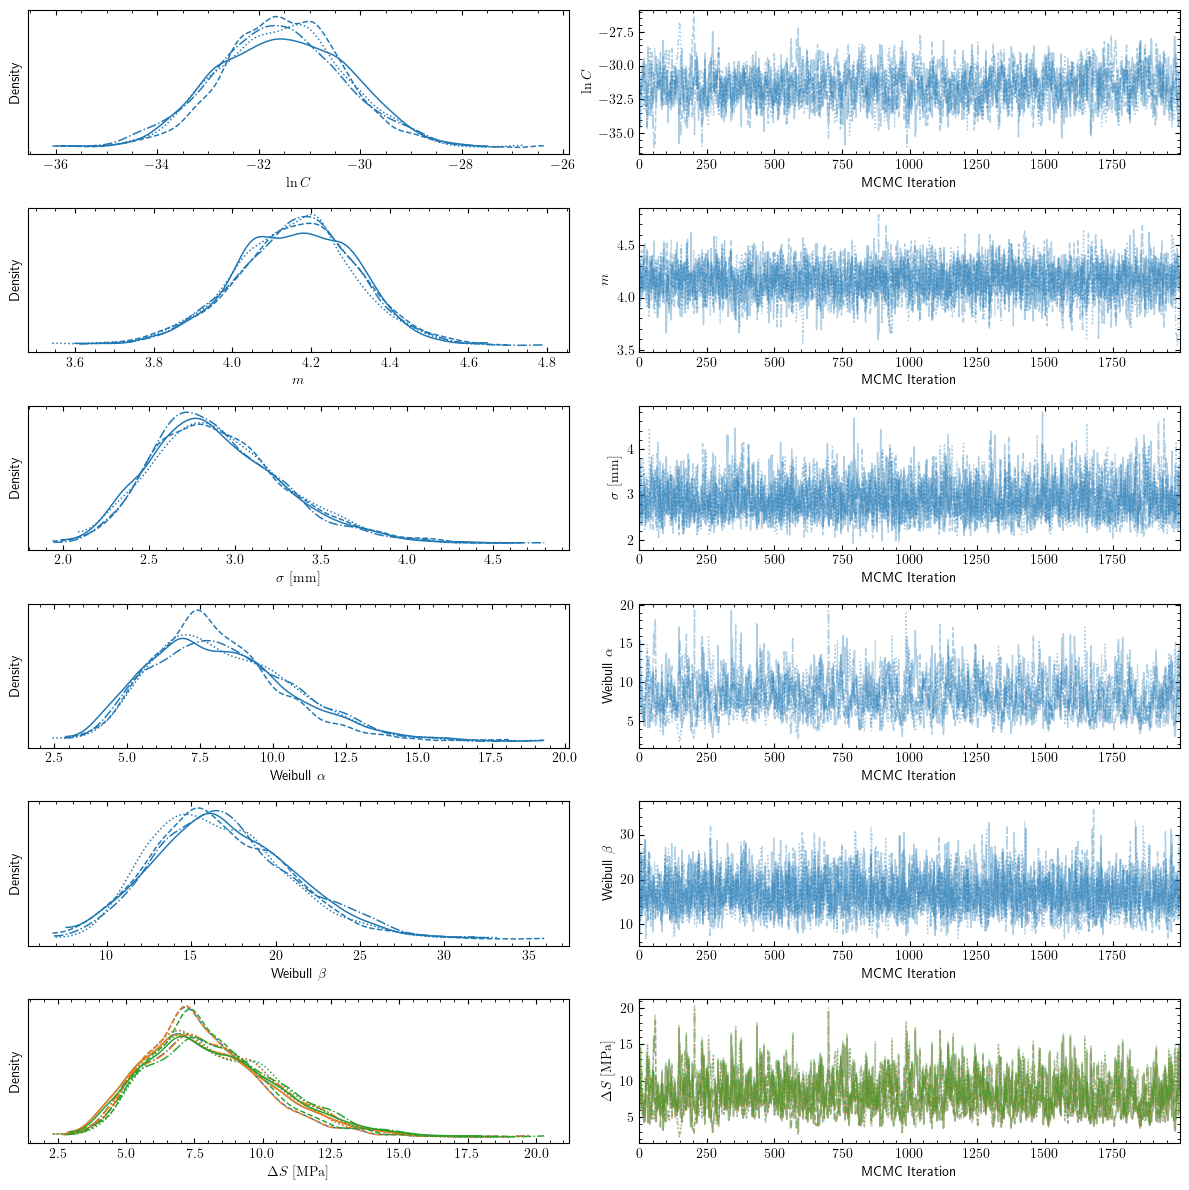

In [64]:
# Visualize MTL posterior traces to check convergence
from src.visualisation import plot_posterior_trace

# Define variables to plot - include shared parameters and hyperpriors
mtl_var_names = ["logc", "m", "noise_std", "weibull_concentration", "weibull_scale", "ds"]
mtl_plot_labels = [
    r"$\ln C$", 
    r"$m$", 
    r"$\sigma \ \mathrm{[mm]}$",
    r"Weibull $\alpha$",
    r"Weibull $\beta$",
    r"$\Delta S \ \mathrm{[MPa]}$"
]

# Create trace plots for MTL parameters
plot_posterior_trace(
    mtl_results['samples'], 
    var_names=mtl_var_names, 
    plot_var_names=mtl_plot_labels,
    compact=True,
    save_fig_name="post_trace_mtl_fh_spectral.pdf")

Immediately, we can see that the model suffers by poor identifiability of the stress ranges. Let's see what happens when we plot the prior compared to the posterior for the population-level parameters, and the individual posteriors for the stress ranges. We do the latter since we do not have actual priors.

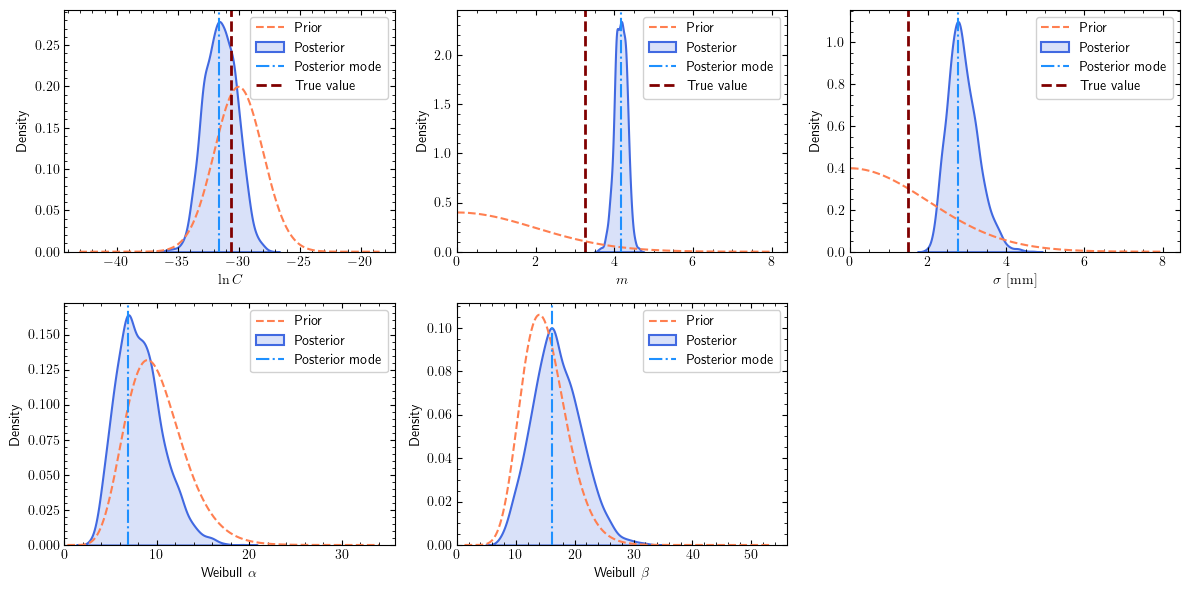

In [65]:
# Compare MTL priors vs posteriors with true values for ALL parameters
from src.visualisation import plot_prior_posterior_comparison

# First, let's create extended priors that include all parameters in the MTL model
# We need to add component-specific priors for stress ranges
mtl_extended_priors = mtl_priors.copy()  # Start with population-level priors
# Also add the hyperpriors to the extended priors dictionary
mtl_extended_priors.update(hyperpriors)

# Define true values for ALL MTL parameters
mtl_extended_true_values = {
    # Population-level parameters (shared across components)
    "logc": true_logc,  # True shared logC
    "m": true_m,        # True shared m  
    "noise_std": 1.5,   # True observation noise
    
    # Stress range parameters (component-specific) also do not have "true" values
    # so they don't get vertical lines
    
    # Hyperpriors don't have "true" values since they're learned from data
    # We'll omit them from true_values so they don't get vertical lines
}

# Create comprehensive variable list for all MTL parameters
all_mtl_vars = [
    # Population-level (shared) parameters
    "logc", "m", "noise_std",
    # Hyperprior parameters  
    "weibull_concentration", "weibull_scale",
]

# Create display labels for all parameters
all_mtl_labels = {
    # Population-level parameters
    "logc": r"$\ln C$",
    "m": r"$m$", 
    "noise_std": r"$\sigma \ \mathrm{[mm]}$",
    
    # Hyperprior parameters
    "weibull_concentration": r"Weibull $\alpha$",
    "weibull_scale": r"Weibull $\beta$",
}

# Create the comprehensive comparison plot
fig, axes = plot_prior_posterior_comparison(
    posterior_samples=mtl_results['samples'],
    prior_dists=mtl_extended_priors,
    true_values=mtl_extended_true_values,
    var_names=all_mtl_vars,
    plot_var_names=all_mtl_labels,
    figsize=(12.0, 6.0),  # Larger figure to accommodate all parameters
    n_cols=3,              # 3 columns for better layout
    point_estimate='mode',
    save_fig_name="prior_post_comp_mtl_fh_spectral.pdf",
    use_first_chain_only=True,
    prior_range_extension=1.5
)

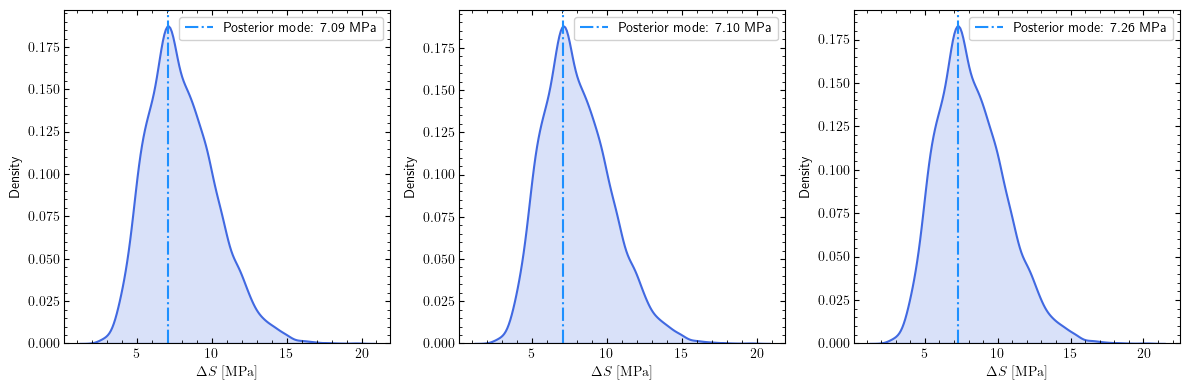

In [66]:
# Demonstrate the new random effects visualization function
from src.visualisation import plot_random_effect_posteriors

# Create the random effects posterior plot
fig, axes = plot_random_effect_posteriors(
    posterior_samples=mtl_results['samples'],
    targets=None,
    param_name="ds",
    plot_var_name=r"$\Delta S \ \mathrm{[MPa]}$",
    figsize=(12.0, 4.0),
    n_cols=3,
    point_estimate='mode',
    save_fig_name="random_effects_mtl_fh_spectral.pdf"
)

Now, let's sample from the posterior predictive distribution and visualise the results for each component. On the left-hand side panel we'll see only crack growth predictions based on the model parameters, while on the right-hand side we'll sample the full posterior predictive which also accounts for the observation noise.

Processing component 1...
Processing component 2...
Processing component 3...


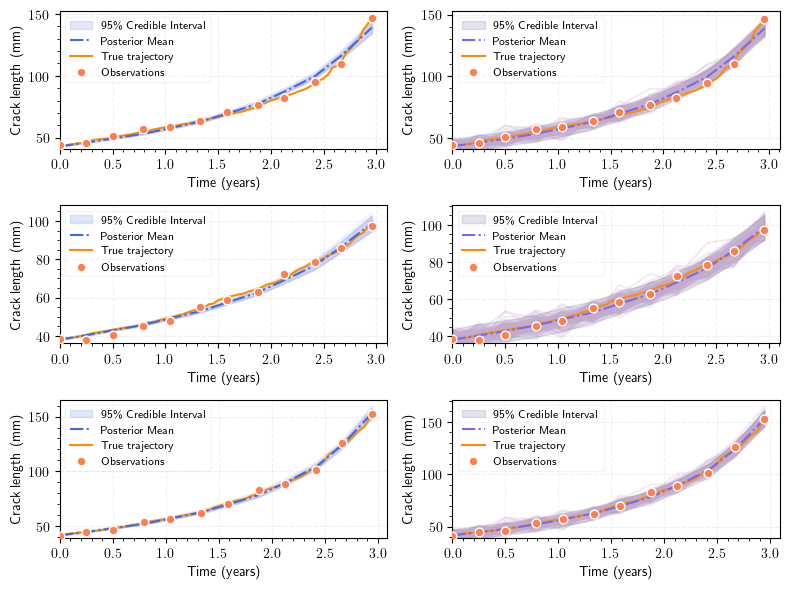

In [68]:
# Demonstration of the refactored MTL visualization function
# The function now takes pre-computed posterior predictions as input
# instead of generating them internally from the model

from src.visualisation import plot_posterior_predictive_mtl

# Step 1: Generate posterior predictions for all components
# Using the MTL model and controlled data from earlier in the notebook

# Generate predictions for each component separately
posterior_predictions_list = []
true_times_list = []
true_crack_lengths_list = []
observed_times_list = []
observed_crack_lengths_list = []

n_components = len(uniform_observations['times'])

for i in range(n_components):
    print(f"Processing component {i+1}...")
    
    # Generate posterior predictions for this component
    predictions = mtl_model.generate_posterior_predictive(
        component_idx=i,  # Component index to predict
        num_samples=500,  # Reduced for demo speed
        Y=1.12,           # Geometry factor
        navg=2.8e6,       # Average cycles per year
        random_seed=42
    )
    
    posterior_predictions_list.append(predictions)
    
    # Extract the true and observed data for this component
    # Use the correct data structure access patterns
    true_times_list.append(selected_trajectories['times'][i])
    true_crack_lengths_list.append(selected_trajectories['crack_lengths'][i])
    observed_times_list.append(uniform_observations['times'][i])
    observed_crack_lengths_list.append(uniform_observations['noisy_crack_lengths'][i])


# Step 2: Use the refactored visualization function
# This demonstrates the new interface pattern that separates prediction generation from visualization

# Plot predictions (showing model predictions vs true trajectories)
fig1, ax1, stats1 = plot_posterior_predictive_mtl(
    posterior_predictions_list=posterior_predictions_list,
    true_times_list=true_times_list,
    true_crack_lengths_list=true_crack_lengths_list,
    observed_times_list=observed_times_list,
    observed_crack_lengths_list=observed_crack_lengths_list,
    max_samples=100,
    figsize=(8., 6.),
    save_fig_name="post_pred_mtl_fh_spectral.pdf"
)

And let's cap things off by summarising performance results. We'll print these in table format first and then look at some error metrics using a bar chart.

In [69]:
# Store results
mtl_component_results = []

for i in range(mtl_results['samples']['ds'].shape[2]):
    mtl_component_results.append({
        'index': i,
        'true_params': {
            'logc': true_logc,
            'm': true_m,
            'noise_std': 1.5  # The true noise std used for generating observations
        },
        'inferred_params': {
            'logc': mtl_results['samples']['logc'],
            'm': mtl_results['samples']['m'],
            'ds': mtl_results['samples']['ds'][:, :, i],
            'noise_std': mtl_results['samples']['noise_std'],
        }
        })

In [70]:
from src.output_utils import create_comparison_summary, save_comparison_summary

In [71]:
mtl_summary_df = create_comparison_summary(mtl_component_results)
display(mtl_summary_df.T)

,0,1,2
Component,Component 1,Component 2,Component 3
logc_target,-30.66693,-30.66693,-30.66693
logc_mean,-31.542316,-31.542316,-31.542316
logc_std,1.257135,1.257135,1.257135
logc_hdi_lower,-33.825527,-33.825527,-33.825527
logc_hdi_upper,-28.964424,-28.964424,-28.964424
logc_rmse,1.531891,1.531891,1.531891
logc_mape,4.040754,4.040754,4.040754
m_target,3.2491,3.2491,3.2491
m_mean,4.160108,4.160108,4.160108


We can also save it to an excel file for good measure.

In [37]:
save_comparison_summary(mtl_summary_df, "mtl_fh_spectral_comparison_summary", "excel")

'/Users/nikos/Library/CloudStorage/OneDrive-Personal/Research (NTUA)/Postdoctoral Research/Stochastic Crack Growth Monitoring/Code/outputs/mtl_fh_spectral_comparison_summary.xlsx'

And the piece de resistance...

In [72]:
from src.visualisation import plot_performance_metrics

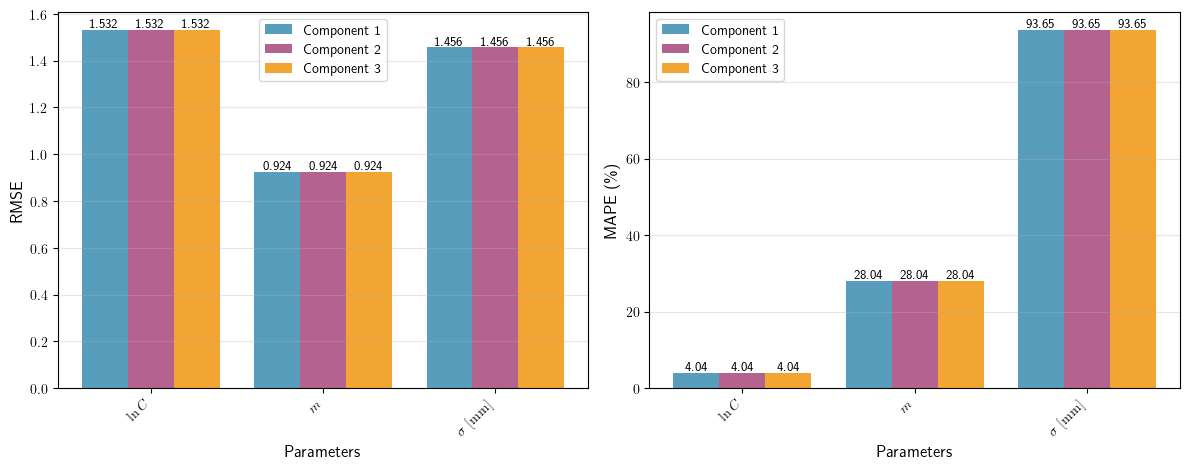

In [73]:
mtl_plot_labels = {
    "logc": r"$\ln C$",
    "m": r"$m$",
    "noise_std": r"$\sigma \ \mathrm{[mm]}$"
}
fig, ax = plot_performance_metrics(summary_df=mtl_summary_df,
                        parameter_labels=mtl_plot_labels,
                        figsize=(12., 4.8),
                        colors=['#2E86AB', '#A23B72', '#F18F01'],
                        save_fig_name="mtl_fh_spectral_performance_comparison.pdf")

Now, let's try to modify the model structure to see whether we may improve identifiability in terms of the Paris' parameters. Specifically, considering that we have a relatively small number of components, let's treat the stress ranges as independent random variables with idependent, identically distributed Weibull prior distributions with fixed parameters.

In [74]:
# Define priors for Multi-Task Learning (MTL) without conditional hyperpriors
import numpyro.distributions as dist

# MTL priors for shared parameters (fixed effects)
mtl_priors = {
    "logc": dist.Normal(-30.0, 2.0),       # Shared Paris law C parameter
    "m": dist.HalfNormal(2.0),            # Shared Paris law exponent
    "noise_std": dist.HalfNormal(2.0)      # Shared observation noise
}

# Optional hyperpriors for stress range distribution (enables hierarchical modeling)
# When provided, stress ranges follow: ds[i] ~ Weibull(concentration, scale)
# When None, stress ranges are i.i.d. with fixed Weibull(14.9, 1.6) prior
hyperpriors = None

In [75]:
# Create the hierarchical MTL model
# The hyperpriors argument enables conditional hyperprior functionality
mtl_iid_model = MTLBayesianModel(
    priors=mtl_priors,                    # Fixed effects priors
    crack_growth_data=uniform_observations, # Multi-component observations
    hyperpriors=hyperpriors               # Enables hierarchical stress range modeling
)

print("MTL Model Configuration:")
print(f"- Number of components: {len(uniform_observations['times'])}")
print(f"- Shared parameters: {list(mtl_priors.keys())}")
print(f"- Component-specific parameters: stress ranges (ds)")
print(f"- Hyperprior mode: {'Hierarchical' if hyperpriors else 'Simple'}")
print(f"- Observations per component: {[len(times) for times in uniform_observations['times']]}")

MTL Model Configuration:
- Number of components: 3
- Shared parameters: ['logc', 'm', 'noise_std', 'ds']
- Component-specific parameters: stress ranges (ds)
- Hyperprior mode: Simple
- Observations per component: [12, 12, 12]


In [76]:
# Run hierarchical MTL inference
print("Running hierarchical Multi-Task Learning inference...")
print("This jointly learns from all components while sharing information about:")
print("- Material properties (logC, m)")
print("- Measurement system (noise_std)")
print("- Stress range component distributions (independently)")

mtl_results = mtl_iid_model.run_inference(
    navg=2.8e6,           # Average cycles per year
    num_warmup=2000,      # MCMC warmup steps
    num_samples=2000,     # MCMC samples to collect
    num_chains=4,         # Number of parallel chains
    progress_bar=True     # Show progress during sampling
)
print("\nInference completed!")

Running hierarchical Multi-Task Learning inference...
This jointly learns from all components while sharing information about:
- Material properties (logC, m)
- Measurement system (noise_std)
- Stress range component distributions (independently)


sample: 100%|██████████| 4000/4000 [00:04<00:00, 914.44it/s, 1023 steps of size 2.02e-03. acc. prob=0.95]



Inference completed!


In [77]:
import numpy as np
# Extract the true parameters for this component from the selected trajectories
true_logc = np.log(selected_trajectories['paris_c'][0])
true_m = selected_trajectories['paris_m'][0]
# Print information about the inference
print(f"Inferred shared parameters:")
print(f"  logC: {mtl_results['summary']['mean']['logc']:.4f} ± {mtl_results['summary']['sd']['logc']:.4f} (true: {true_logc:.4f})")
print(f"  m: {mtl_results['summary']['mean']['m']:.4f} ± {mtl_results['summary']['sd']['m']:.4f} (true: {true_m:.4f})")
print(f"  noise_std: {mtl_results['summary']['mean']['noise_std']:.4f} ± {mtl_results['summary']['sd']['noise_std']:.4f} (true: 1.5 mm)")

print(f"\nInferred component stress ranges:")
for i in range(3):
    mean_ds = mtl_results['summary']['mean'][f'ds[{i}]']
    sd_ds = mtl_results['summary']['sd'][f'ds[{i}]']
    print(f"  Component {i+1}: {mean_ds:.2f} ± {sd_ds:.2f} MPa")

Inferred shared parameters:
  logC: -32.0210 ± 1.5080 (true: -30.6669)
  m: 4.1390 ± 0.1590 (true: 3.2491)
  noise_std: 2.9120 ± 0.3890 (true: 1.5 mm)

Inferred component stress ranges:
  Component 1: 9.44 ± 3.42 MPa
  Component 2: 9.44 ± 3.41 MPa
  Component 3: 9.67 ± 3.51 MPa


We can summarise inference results by printing the main posterior statistics and convergence metrics, alongside KDEs of the parameter posterior densities and their corresponding trace-plots.

In [78]:
# Print full posterior summary
mtl_iid_model.summarise_posterior(print_summary=True)
# Print summary statistics
print("\nPosterior summary:")

                                   mean     sd   hdi_3%  hdi_97%  mcse_mean  \
ds[0]                             9.440  3.418    3.744   16.019      0.135   
ds[1]                             9.435  3.406    3.829   16.048      0.135   
ds[2]                             9.674  3.506    3.818   16.410      0.139   
logc                            -32.021  1.508  -34.957  -29.262      0.058   
m                                 4.139  0.159    3.838    4.429      0.004   
noise_std                         2.912  0.389    2.247    3.662      0.009   
predicted_crack_lengths[0, 0]    45.994  0.089   45.825   46.157      0.002   
predicted_crack_lengths[0, 1]    49.334  0.188   48.989   49.688      0.004   
predicted_crack_lengths[0, 2]    53.195  0.296   52.638   53.736      0.007   
predicted_crack_lengths[0, 3]    57.707  0.414   56.951   58.493      0.009   
predicted_crack_lengths[0, 4]    63.046  0.540   62.056   64.067      0.012   
predicted_crack_lengths[0, 5]    69.456  0.672   68.

Looks like the model has convergeed successfully. Let's get a visual assessment.

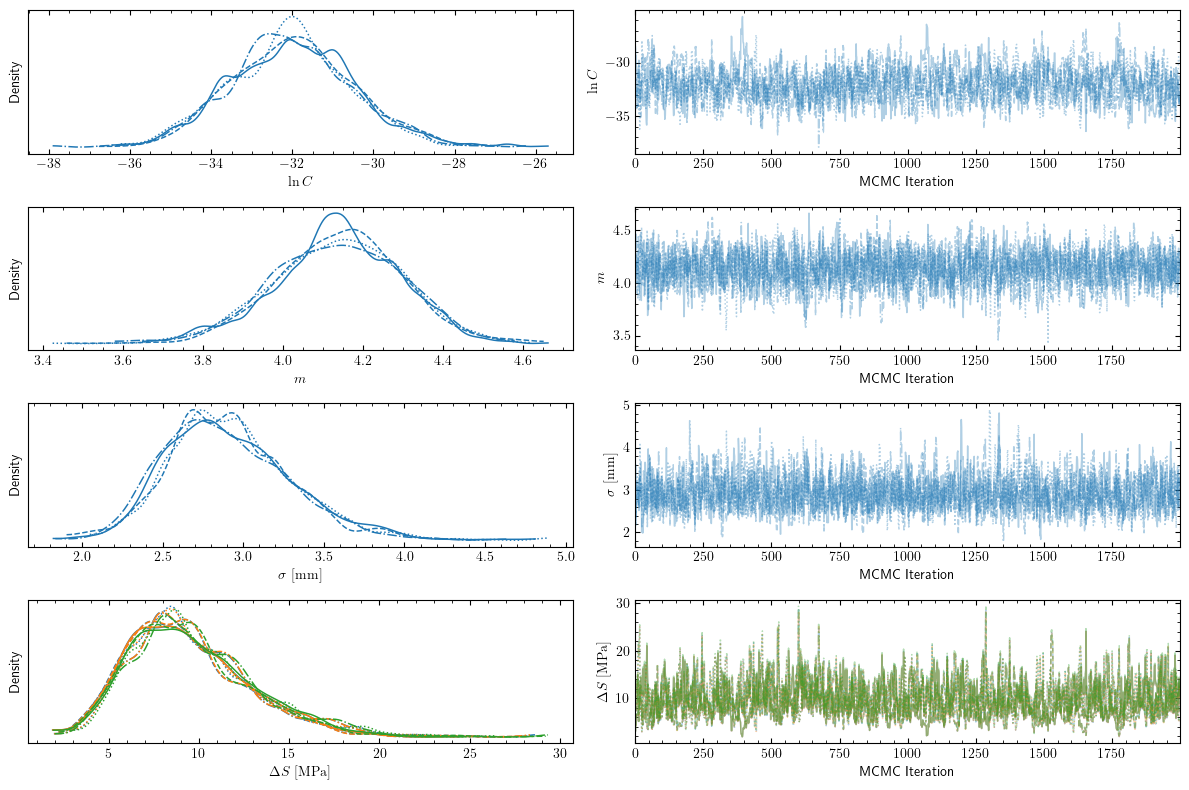

In [79]:
# Visualize MTL posterior traces to check convergence
from src.visualisation import plot_posterior_trace

# Define variables to plot - include shared parameters and hyperpriors
mtl_var_names = ["logc", "m", "noise_std", "ds"]
mtl_plot_labels = [
    r"$\ln C$", 
    r"$m$", 
    r"$\sigma \ \mathrm{[mm]}$",
    r"$\Delta S \ \mathrm{[MPa]}$"
]

# Create trace plots for MTL parameters
plot_posterior_trace(
    mtl_results['samples'], 
    var_names=mtl_var_names, 
    plot_var_names=mtl_plot_labels,
    compact=True,
    save_fig_name="post_trace_mtl_iid_spectral.pdf")

The model has not been improved. At least, not substantially! There are two key take-aways here:
- The model fit to the data is controlled by the population-level parameters, with the stress ranges playing a minimal role.
- This indirectly points to the fact that the equivalent stress range assumption is poor, and thus the model tends to downplay its importance.

However, we will still extract results following the same procedure as before for completeness.

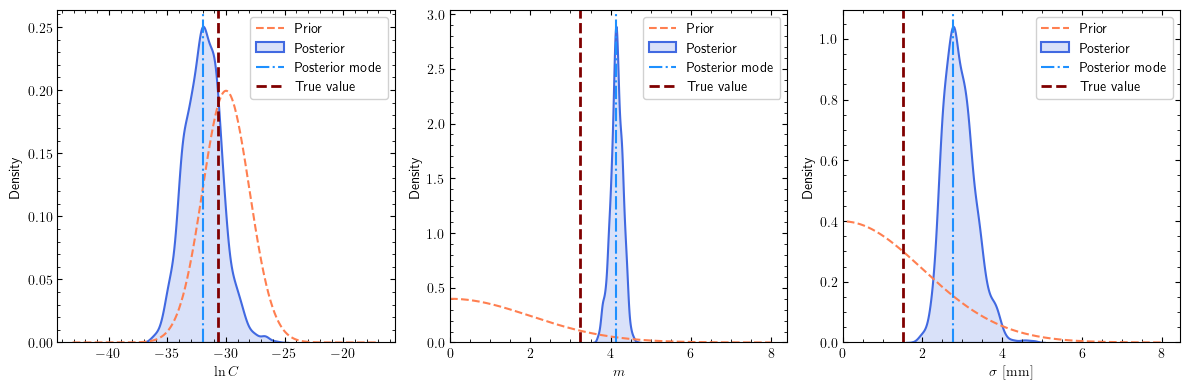

In [80]:
# Compare MTL priors vs posteriors with true values for ALL parameters
from src.visualisation import plot_prior_posterior_comparison

# First, let's create extended priors that include all parameters in the MTL model
# We need to add component-specific priors for stress ranges
mtl_extended_priors = mtl_priors.copy()  # Start with population-level priors

# Define true values for ALL MTL parameters
mtl_extended_true_values = {
    # Population-level parameters (shared across components)
    "logc": true_logc,  # True shared logC
    "m": true_m,        # True shared m  
    "noise_std": 1.5,   # True observation noise
    
    # Stress range parameters (component-specific) also do not have "true" values
    # so they don't get vertical lines
    
    # Hyperpriors don't have "true" values since they're learned from data
    # We'll omit them from true_values so they don't get vertical lines
}

# Create comprehensive variable list for all MTL parameters
all_mtl_vars = [
    # Population-level (shared) parameters
    "logc", "m", "noise_std"
]

# Create display labels for all parameters
all_mtl_labels = {
    # Population-level parameters
    "logc": r"$\ln C$",
    "m": r"$m$",
    "noise_std": r"$\sigma \ \mathrm{[mm]}$",
}

# Create the comprehensive comparison plot
fig, axes = plot_prior_posterior_comparison(
    posterior_samples=mtl_results['samples'],
    prior_dists=mtl_extended_priors,
    true_values=mtl_extended_true_values,
    var_names=all_mtl_vars,
    plot_var_names=all_mtl_labels,
    figsize=(12.0, 4.0),  # Larger figure to accommodate all parameters
    n_cols=3,              # 3 columns for better layout
    point_estimate='mode',
    save_fig_name="prior_post_comp_mtl_iid_spectral.pdf",
    use_first_chain_only=True,
    prior_range_extension=1.5
)

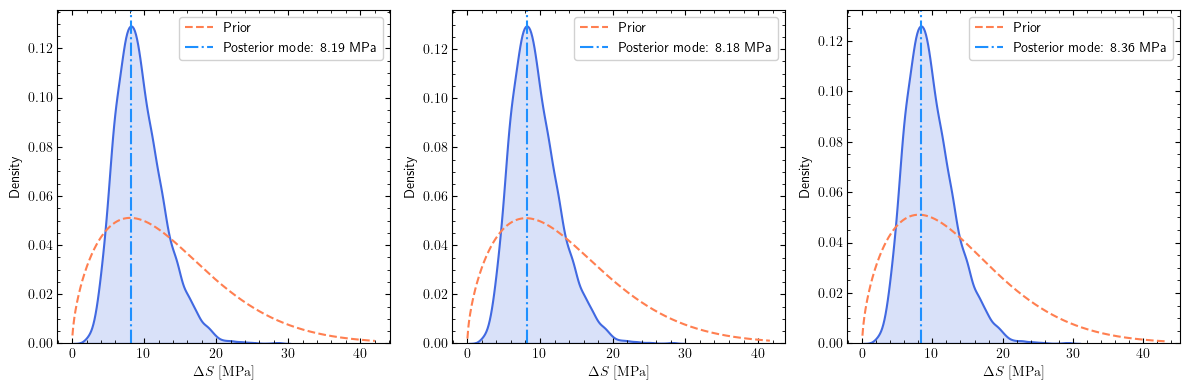

In [81]:
# Let's create a dictionary with the i.i.d prior signatures
# to use for plotting the random effects posteriors along
# with their priors 
random_effects_priors = {
    f"ds[{i}]": dist.Weibull(14.9, 1.6) for i in range(3)
}

# Create the random effects posterior plot
fig, axes = plot_random_effect_posteriors(
    posterior_samples=mtl_results['samples'],
    targets=None,
    param_name="ds",
    plot_var_name=r"$\Delta S \ \mathrm{[MPa]}$",
    figsize=(12.0, 4.0),
    n_cols=3,
    point_estimate='mode',
    save_fig_name="random_effects_mtl_iid_spectral.pdf",
    priors=random_effects_priors
)

Processing component 1...
Processing component 2...
Processing component 3...


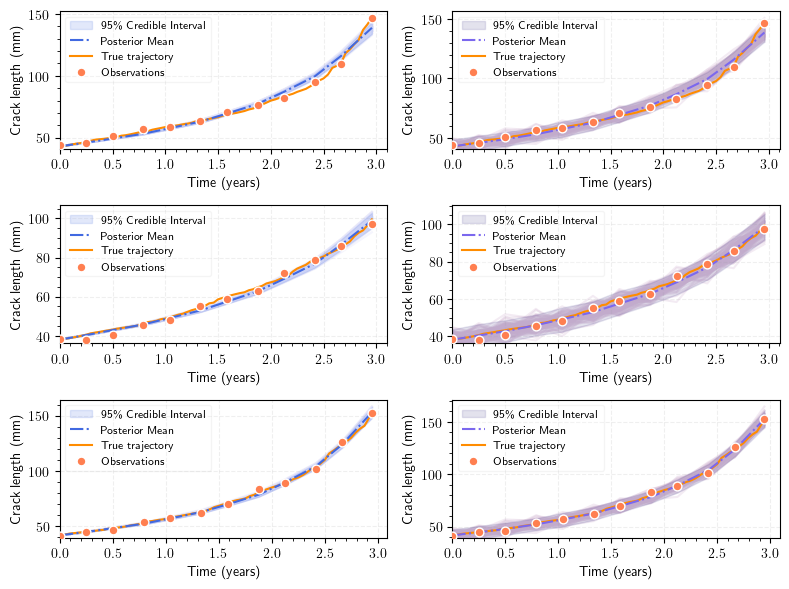

In [82]:
# We'll close things off with the posterior predictive sampling
# and visualisation for the i.i.d MTL model

# Generate predictions for each component separately
posterior_predictions_list = []
true_times_list = []
true_crack_lengths_list = []
observed_times_list = []
observed_crack_lengths_list = []

n_components = len(uniform_observations['times'])

for i in range(n_components):
    print(f"Processing component {i+1}...")
    
    # Generate posterior predictions for this component
    predictions = mtl_iid_model.generate_posterior_predictive(
        component_idx=i,  # Component index to predict
        num_samples=500,  # Reduced for demo speed
        Y=1.12,           # Geometry factor
        navg=2.8e6,       # Average cycles per year
        random_seed=42
    )
    
    posterior_predictions_list.append(predictions)
    
    # Extract the true and observed data for this component
    # Use the correct data structure access patterns
    true_times_list.append(selected_trajectories['times'][i])
    true_crack_lengths_list.append(selected_trajectories['crack_lengths'][i])
    observed_times_list.append(uniform_observations['times'][i])
    observed_crack_lengths_list.append(uniform_observations['noisy_crack_lengths'][i])


# Step 2: Use the refactored visualization function
# This demonstrates the new interface pattern that separates prediction generation from visualization

# Plot predictions (showing model predictions vs true trajectories)
fig1, ax1, stats1 = plot_posterior_predictive_mtl(
    posterior_predictions_list=posterior_predictions_list,
    true_times_list=true_times_list,
    true_crack_lengths_list=true_crack_lengths_list,
    observed_times_list=observed_times_list,
    observed_crack_lengths_list=observed_crack_lengths_list,
    max_samples=100,
    figsize=(8., 6.),
    save_fig_name="post_pred_mtl_iid_spectral.pdf"
)

In [83]:
# Store results
mtl_iid_component_results = []

for i in range(mtl_results['samples']['ds'].shape[2]):
    mtl_iid_component_results.append({
        'index': i,
        'true_params': {
            'logc': true_logc,
            'm': true_m,
            'noise_std': 1.5  # The true noise std used for generating observations
        },
        'inferred_params': {
            'logc': mtl_results['samples']['logc'],
            'm': mtl_results['samples']['m'],
            'ds': mtl_results['samples']['ds'][:, :, i],
            'noise_std': mtl_results['samples']['noise_std'],
        }
        })

In [84]:
mtl_iid_summary_df = create_comparison_summary(mtl_iid_component_results)
display(mtl_iid_summary_df.T)

,0,1,2
Component,Component 1,Component 2,Component 3
logc_target,-30.66693,-30.66693,-30.66693
logc_mean,-32.021271,-32.021271,-32.021271
logc_std,1.50793,1.50793,1.50793
logc_hdi_lower,-35.009102,-35.009102,-35.009102
logc_hdi_upper,-29.09864,-29.09864,-29.09864
logc_rmse,2.026841,2.026841,2.026841
logc_mape,5.450797,5.450797,5.450797
m_target,3.2491,3.2491,3.2491
m_mean,4.139143,4.139143,4.139143


We can also save it to an excel file for good measure.

In [67]:
save_comparison_summary(mtl_iid_summary_df, "mtl_iid_spectral_comparison_summary", "excel")

'/Users/nikos/Library/CloudStorage/OneDrive-Personal/Research (NTUA)/Postdoctoral Research/Stochastic Crack Growth Monitoring/Code/outputs/mtl_iid_spectral_comparison_summary.xlsx'

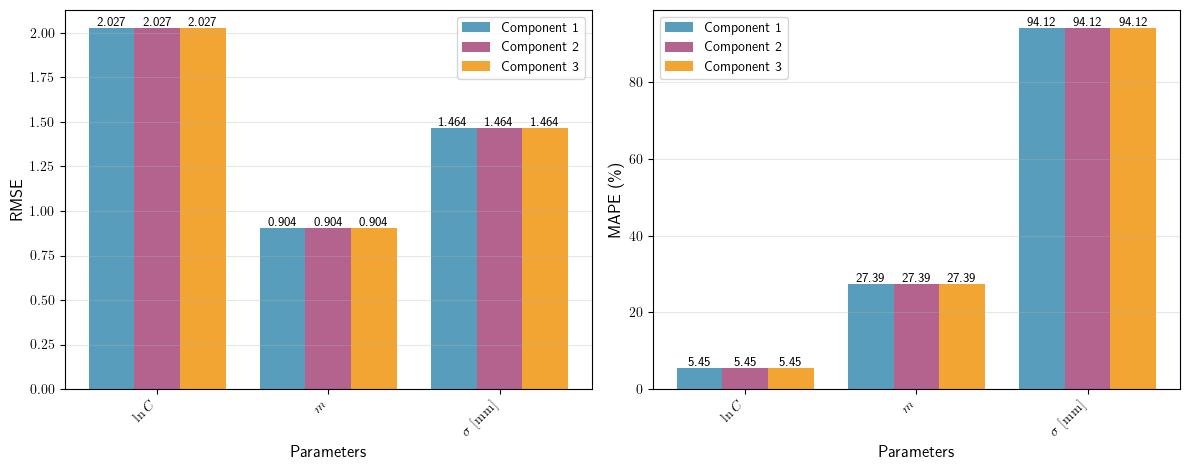

In [85]:
mtl_plot_labels = {
    "logc": r"$\ln C$",
    "m": r"$m$",
    "noise_std": r"$\sigma \ \mathrm{[mm]}$"
}
fig, ax = plot_performance_metrics(summary_df=mtl_iid_summary_df,
                        parameter_labels=mtl_plot_labels,
                        figsize=(12., 4.8),
                        colors=['#2E86AB', '#A23B72', '#F18F01'],
                        save_fig_name="mtl_iid_spectral_performance_comparison.pdf")